<div style="background: linear-gradient(90deg, #0b6623 0%, #2e8b57 50%, #98fb98 100%); padding: 20px; border-radius: 12px; text-align: center;">
  <h1 style="color: white; margin: 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, 'Helvetica Neue', Arial; font-weight: 700; font-size: 2.2rem;">
    Lab 3 Part 1
  </h1>
</div>

## Practical Work 2

For this practical work, the trainees will have to develop a Python program that is able to implement the gradient descent variants (Batch/Mini-Batch/Stochastic) in order to achieve the linear regression of a set of datapoints.
##### Please notice that we will apply these algorithm to single variable LR.

#### Import numpy, matplotlib.pyplot and make it inline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
%matplotlib inline

To have a dataset or set of data points, the trainee must generate a pair of arrays <b>X</b> and <b>y</b> with the values in <b>X</b> equally distributed between <b>0</b> and <b>20</b> and the values in <b>y</b> such that:
<b>yi = a*xi + b (and a = -2, b = 1)</b>

In [2]:
X = np.linspace(0,20)
X

array([ 0.        ,  0.40816327,  0.81632653,  1.2244898 ,  1.63265306,
        2.04081633,  2.44897959,  2.85714286,  3.26530612,  3.67346939,
        4.08163265,  4.48979592,  4.89795918,  5.30612245,  5.71428571,
        6.12244898,  6.53061224,  6.93877551,  7.34693878,  7.75510204,
        8.16326531,  8.57142857,  8.97959184,  9.3877551 ,  9.79591837,
       10.20408163, 10.6122449 , 11.02040816, 11.42857143, 11.83673469,
       12.24489796, 12.65306122, 13.06122449, 13.46938776, 13.87755102,
       14.28571429, 14.69387755, 15.10204082, 15.51020408, 15.91836735,
       16.32653061, 16.73469388, 17.14285714, 17.55102041, 17.95918367,
       18.36734694, 18.7755102 , 19.18367347, 19.59183673, 20.        ])

In [3]:
X.shape

(50,)

In [4]:
a=-2
b=1
y=a*X+b
y

array([  1.        ,   0.18367347,  -0.63265306,  -1.44897959,
        -2.26530612,  -3.08163265,  -3.89795918,  -4.71428571,
        -5.53061224,  -6.34693878,  -7.16326531,  -7.97959184,
        -8.79591837,  -9.6122449 , -10.42857143, -11.24489796,
       -12.06122449, -12.87755102, -13.69387755, -14.51020408,
       -15.32653061, -16.14285714, -16.95918367, -17.7755102 ,
       -18.59183673, -19.40816327, -20.2244898 , -21.04081633,
       -21.85714286, -22.67346939, -23.48979592, -24.30612245,
       -25.12244898, -25.93877551, -26.75510204, -27.57142857,
       -28.3877551 , -29.20408163, -30.02040816, -30.83673469,
       -31.65306122, -32.46938776, -33.28571429, -34.10204082,
       -34.91836735, -35.73469388, -36.55102041, -37.36734694,
       -38.18367347, -39.        ])

### Plot X vs. y

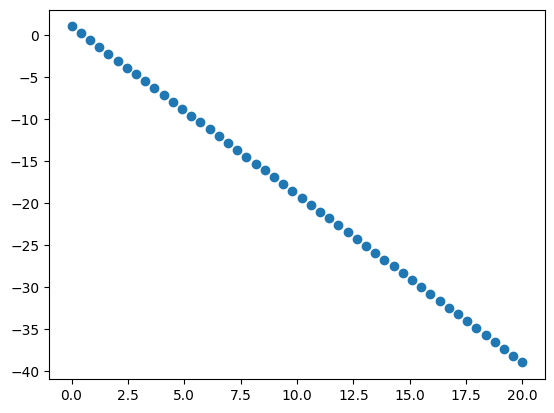

In [5]:
plt.scatter(X,y)

#### Use your code from practical session 1 and create a function to perform GD for single variable linear regression.
#### The function should take the following input parameters:
##### Input data (X), Target Labels (y), Learning Rate (alpha), Maximum number of iterations
#### The function should return the following:
##### All Theta_0 and Theta_1 values till converge, and equivellant Losses, all hypothesis output, and optimum values of Theta_0 and Theta_1
#### Implement the stop criteria (Gradient Check).
#### Implement the convergence check (cost check).
#### You can use any small values for stop criteria and convergence check. However, the used values in the current implementation used 0.001 for both.

In [6]:
import numpy as np

def GD_1(X: np.array, y: np.array, alpha: float, max_iter: int):
    m = len(X)
    Xp = np.c_[np.ones((m, 1)), X]
    y = y.reshape(-1, 1)

    thetas = np.zeros((Xp.shape[1], 1))

    losses_history = []
    theta0_history = [thetas[0, 0]]
    theta1_history = [thetas[1, 0]]
    hyp = []
    grad = []
    prev_err=0
    for i in range(max_iter):

        hypothesis = Xp @ thetas
        hyp.append(hypothesis.copy())


        loss = np.mean((hypothesis - y) ** 2)
        losses_history.append(loss)


        gradient = (Xp.T @ (hypothesis - y)) / m
        grad.append(gradient.copy())


        thetas -= alpha * gradient


        theta0_history.append(thetas[0, 0])
        theta1_history.append(thetas[1, 0])

        if np.linalg.norm(gradient)<0.001:
          print("Gradient Check Passed")
          break
        if(np.abs(prev_err-loss)<0.001):
          print("Convergence Check Passed")
          break

        prev_err=loss

    grad_norm = np.linalg.norm(gradient)

    return theta0_history, theta1_history, losses_history, hyp, grad_norm, grad

#### Try your function with any input parameterss of your choice.
##### The following results uses alpha = 0.0005 and max. iterations = 300.

In [7]:
theta0h,theta1h,lossesh,hyph,grad_norm,grad=GD_1(X,y,0.0005,300)


for i in range(len(X)):
  print("\n")
  print(f"************* iteration {i} *************")
  print(f"h(x): {hyph[i].flatten()}\n")
  print(f"loss: {np.array(lossesh)}\n")
  print(f"j= {lossesh[-1]}")
  print(f"theta0: {theta0h[-1]}")
  print(f"theta1: {theta1h[-1]}")



Convergence Check Passed


************* iteration 0 *************
h(x): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]

loss: [4.99775510e+02 4.34422853e+02 3.77621703e+02 3.28253078e+02
 2.85344419e+02 2.48050427e+02 2.15636413e+02 1.87463821e+02
 1.62977655e+02 1.41695539e+02 1.23198216e+02 1.07121291e+02
 9.31480503e+01 8.10032233e+01 7.04475585e+01 6.12731110e+01
 5.32991459e+01 4.63685779e+01 4.03448765e+01 3.51093765e+01
 3.05589403e+01 2.66039260e+01 2.31664215e+01 2.01787098e+01
 1.75819345e+01 1.53249410e+01 1.33632681e+01 1.16582726e+01
 1.01763678e+01 8.88836188e+00 7.76888275e+00 6.79587840e+00
 5.95018233e+00 5.21513602e+00 4.57626074e+00 4.02097234e+00
 3.53833331e+00 3.11883736e+00 2.75422210e+00 2.43730629e+00
 2.16184837e+00 1.92242350e+00 1.71431669e+00 1.53342992e+00
 1.37620139e+00 1.23953539e+00 1.12074127e+00 1.01748047e+00
 9.27720421e-01 8.49694533e-01 7.8

#### Calculate r2 score

In [8]:
y_pred=theta0h[-1]+theta1h[-1]*X

In [9]:
r2_score(y,y_pred)

0.9975913677635818

##### It is recommended to define a function for each plot. This will help you to easly plot the learning curves when you use different values of hyperparameters.

#### Plot loss vs. epochs

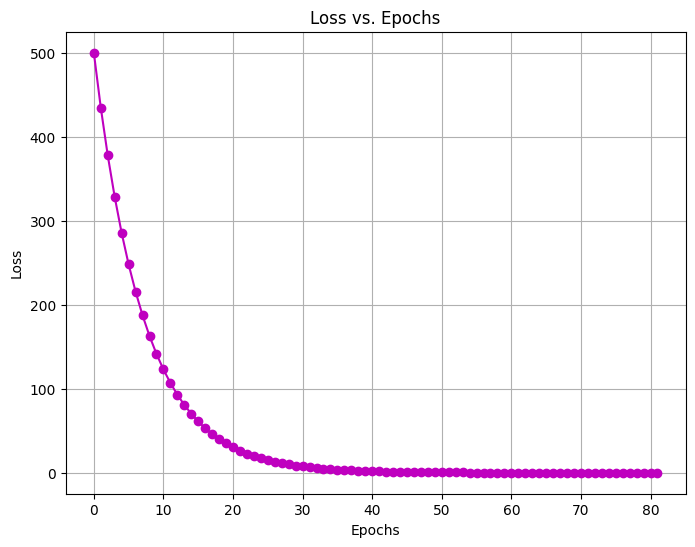

In [10]:
plt.figure(figsize=(8, 6))


plt.plot(lossesh, color='m', marker='o', linestyle='-')

plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


#### Plot Theta_0 vs. loss and Theta_1 vs. loss

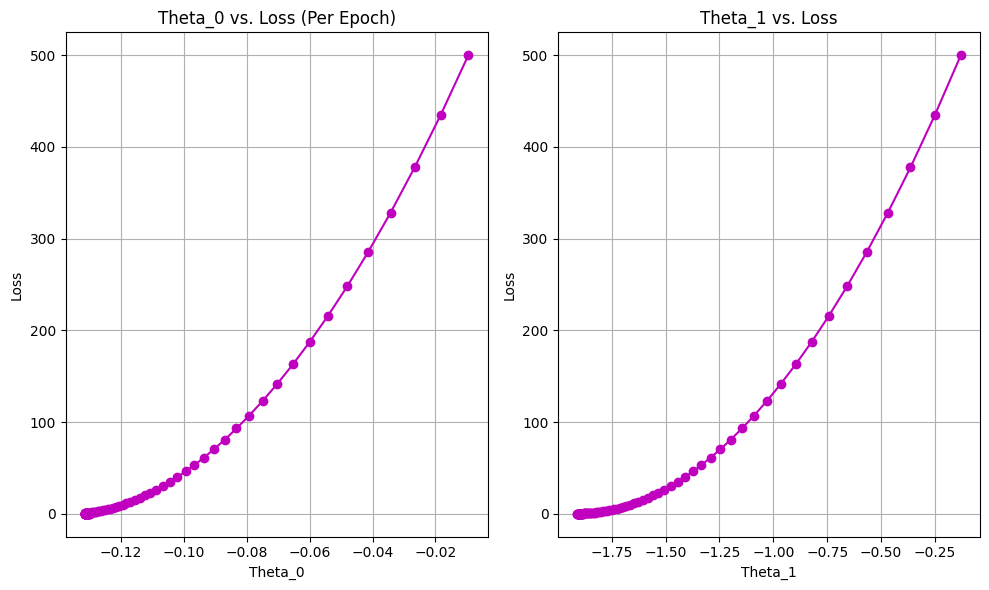

In [11]:
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.plot(theta0h[1:], lossesh, color="m", marker="o", linestyle="-")
plt.title("Theta_0 vs. Loss (Per Epoch)")
plt.xlabel("Theta_0")
plt.ylabel("Loss")
plt.grid(True)


plt.subplot(1,2,2)

plt.plot(theta1h[1:],lossesh,color="m",marker="o",linestyle="-")
plt.title("Theta_1 vs. Loss")
plt.xlabel("Theta_1")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

#### Plot all regression lines till converge

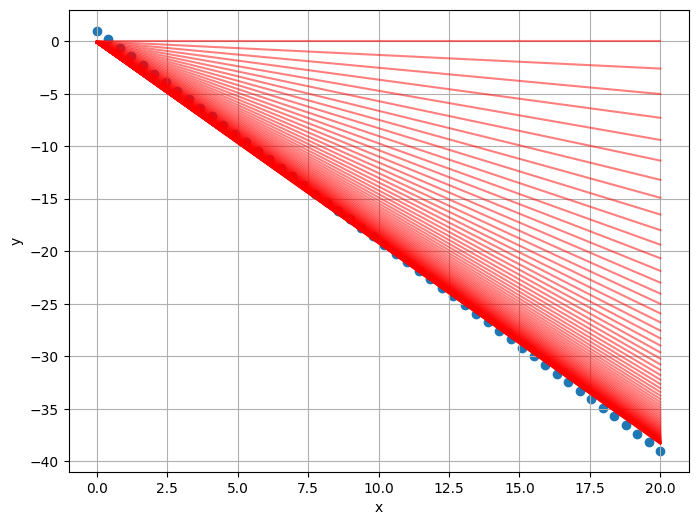

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_regression(x, y, theta0_history, theta1_history):
    plt.figure(figsize=(8, 6))

    plt.scatter(x, y, label='Data points')

    n_lines = len(theta0_history)
    step = max(1, n_lines // 50)

    for i in range(0, n_lines, step):
        y_pred = theta0_history[i] + theta1_history[i] * x
        plt.plot(x, y_pred, color='red', alpha=0.5)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()


plot_all_regression(X, y, theta0h, theta1h)

#### Plot the best regression line

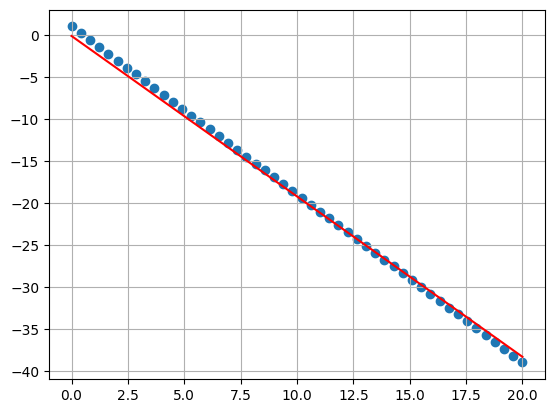

In [13]:
plt.scatter(X,y)
plt.plot(X,y_pred,color="red")
plt.grid()


#### Try different learning rate and number of iterations then plot loss vs. epochs, loss vs. Theat_0 and Theta_1
#### all regression lines till converge, and the best regression line
#### and see the difference in output.

##### The following results uses alpha = 0.00005 and max. iterations = 1000.

In [14]:
theta0h0,theta1h1,lossesh1,hyph1,grad_norm1,grad1=GD_1(X,y,0.00005,1000)


for i in range(len(X)):
  print("\n")
  print(f"************* iteration {i} *************")
  print(f"h(x): {hyph1[i].flatten()}\n")
  print(f"loss: {np.array(lossesh1)}\n")
  print(f"j= {lossesh1[-1]}")
  print(f"theta0: {theta0h0[-1]}")
  print(f"theta1: {theta1h1[-1]}")



Convergence Check Passed


************* iteration 0 *************
h(x): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]

loss: [4.99775510e+02 4.93034113e+02 4.86383710e+02 4.79823074e+02
 4.73350993e+02 4.66966271e+02 4.60667730e+02 4.54454205e+02
 4.48324550e+02 4.42277632e+02 4.36312335e+02 4.30427558e+02
 4.24622212e+02 4.18895226e+02 4.13245542e+02 4.07672117e+02
 4.02173922e+02 3.96749940e+02 3.91399171e+02 3.86120627e+02
 3.80913331e+02 3.75776323e+02 3.70708653e+02 3.65709387e+02
 3.60777600e+02 3.55912381e+02 3.51112833e+02 3.46378069e+02
 3.41707214e+02 3.37099406e+02 3.32553793e+02 3.28069536e+02
 3.23645808e+02 3.19281790e+02 3.14976678e+02 3.10729675e+02
 3.06539998e+02 3.02406873e+02 2.98329536e+02 2.94307235e+02
 2.90339226e+02 2.86424777e+02 2.82563165e+02 2.78753676e+02
 2.74995607e+02 2.71288264e+02 2.67630963e+02 2.64023027e+02
 2.60463791e+02 2.56952597e+02 2.5

In [15]:
y_pred2=theta0h0[-1]+theta1h1[-1]*X
r2_score(y,y_pred2)

0.9971070091157807

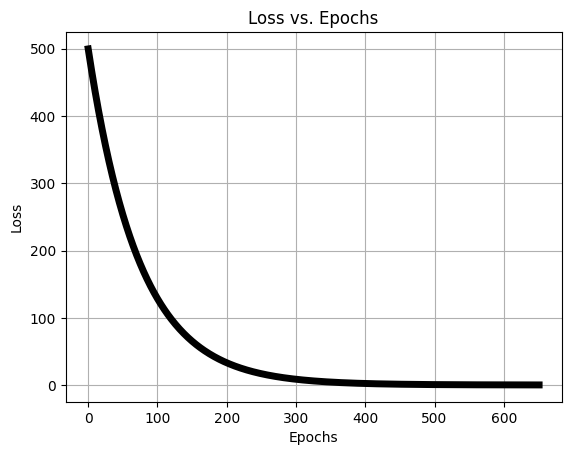

In [16]:
plt.plot(lossesh1, color='black',linewidth=5)
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

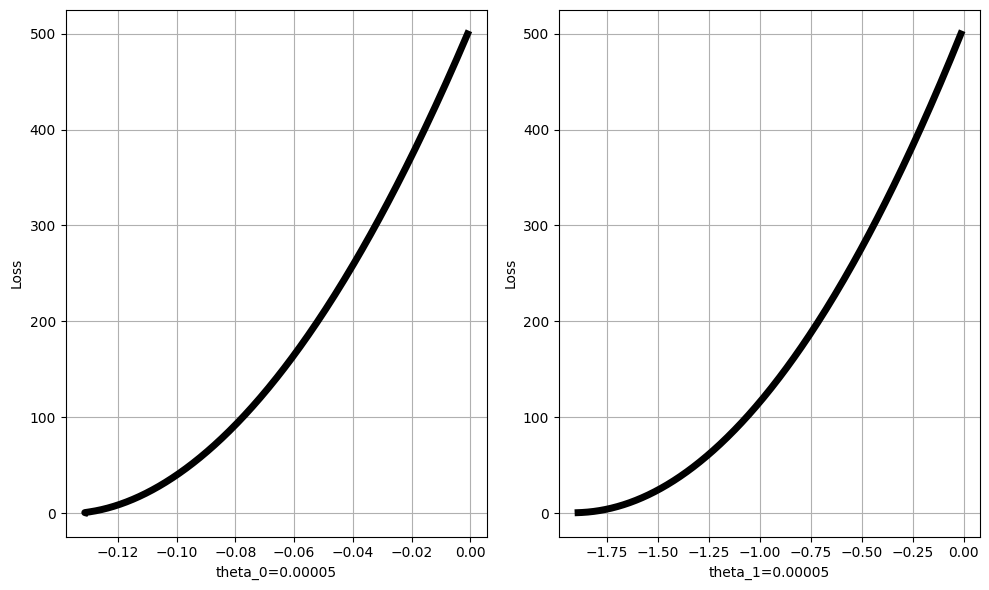

In [17]:
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.plot(theta0h0[1:],lossesh1,color="black",linewidth="5")
plt.xlabel("theta_0=0.00005")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(theta1h1[1:],lossesh1,color="black",linewidth="5")
plt.xlabel("theta_1=0.00005")
plt.ylabel("Loss")
plt.grid(True)

plt.tight_layout()
plt.show()



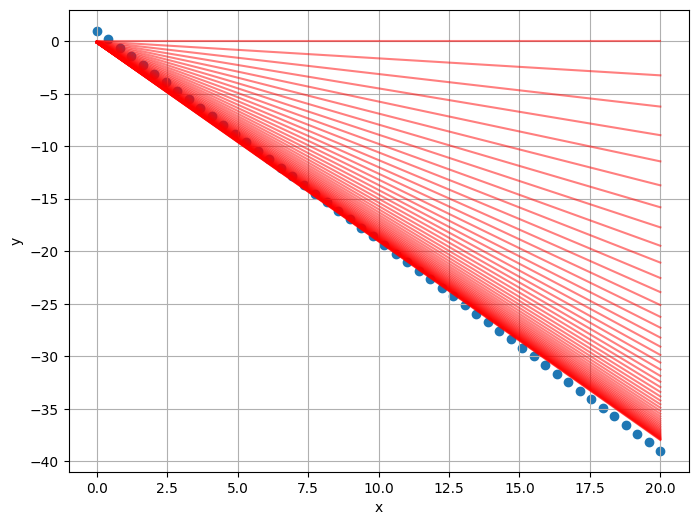

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_regression(x, y, theta0_history, theta1_history):
    plt.figure(figsize=(8, 6))

    plt.scatter(x, y, label='Data points')

    n_lines = len(theta0_history)
    step = max(1, n_lines // 50)

    for i in range(0, n_lines, step):
        y_pred = theta0_history[i] + theta1_history[i] * x
        plt.plot(x, y_pred, color='red', alpha=0.5)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()


plot_all_regression(X, y, theta0h0, theta1h1)

##### The following results uses alpha = 0.005 and max. iterations = 300.

In [19]:
theta0h00,theta1h2,lossesh2,hyph2,grad_norm2,grad2=GD_1(X,y,0.005,200)


# Iterate up to the actual number of iterations the GD_1 function ran
for i in range(len(hyph2)):
  print("\n")
  print(f"************* iteration {i} *************")
  print(f"h(x): {hyph2[i].flatten()}\n")
  print(f"loss: {np.array(lossesh2)}\n")
  print(f"j= {lossesh2[-1]}")
  print(f"theta0: {theta0h00[-1]}")
  print(f"theta1: {theta1h2[-1]}")

Convergence Check Passed


************* iteration 0 *************
h(x): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]

loss: [4.99775510e+02 5.23805059e+01 5.75795131e+00 8.98778125e-01
 3.91652426e-01 3.38043417e-01 3.31696070e-01 3.30275678e-01
 3.29370652e-01]

j= 0.32937065209361416
theta0: -0.12933923711771958
theta1: -1.9159220560570764


************* iteration 1 *************
h(x): [ -0.095       -0.62436277  -1.15372553  -1.6830883   -2.21245106
  -2.74181383  -3.27117659  -3.80053936  -4.32990212  -4.85926489
  -5.38862766  -5.91799042  -6.44735319  -6.97671595  -7.50607872
  -8.03544148  -8.56480425  -9.09416701  -9.62352978 -10.15289254
 -10.68225531 -11.21161808 -11.74098084 -12.27034361 -12.79970637
 -13.32906914 -13.8584319  -14.38779467 -14.91715743 -15.4465202
 -15.97588297 -16.50524573 -17.0346085  -17.56397126 -18.09333403
 -18.62269679 -19.15205956 -19.681422

In [20]:
y_pred3=theta0h00[-1]+theta1h2[-1]*X
r2_score(y,y_pred3)

0.9976327143818681

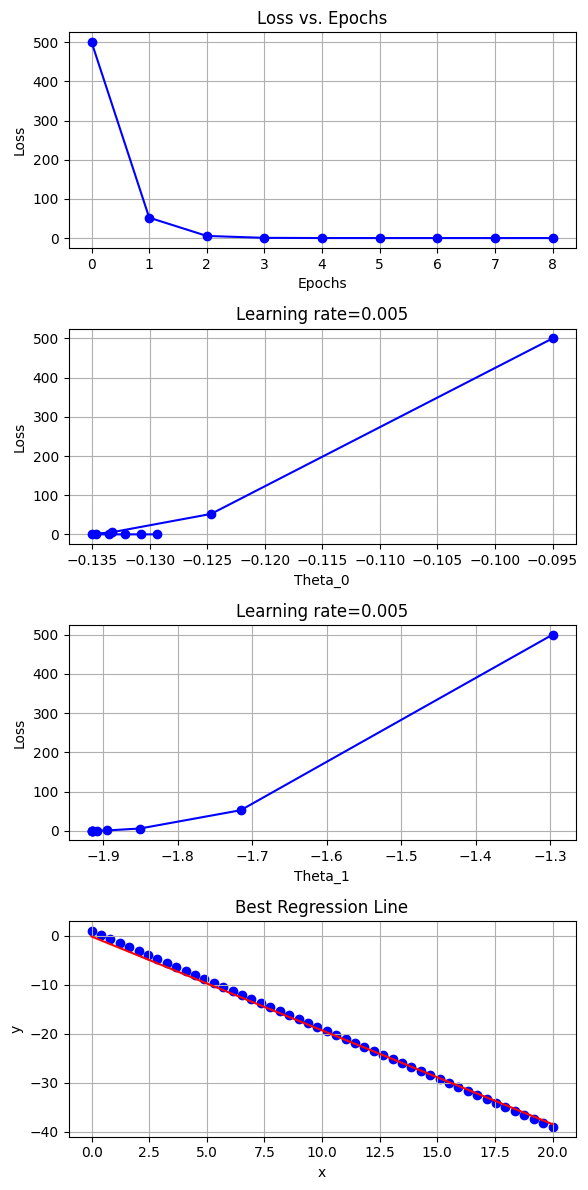

In [36]:
from matplotlib import markers
import matplotlib.pyplot as plt

fig,plots=plt.subplots(4,1,figsize=(6,12))
plots[0].plot(lossesh2,color="blue",marker="o",linestyle="-")
plots[0].set_title("Loss vs. Epochs")
plots[0].set_xlabel("Epochs")
plots[0].set_ylabel("Loss")
plots[0].grid(True)

plots[1].plot(theta0h00[1:],lossesh2,color="blue",marker="o",linestyle="-")
plots[1].set_title("Learning rate=0.005")
plots[1].set_xlabel("Theta_0")
plots[1].set_ylabel("Loss")
plots[1].grid(True)

plots[2].plot(theta1h2[1:],lossesh2,color="blue",marker="o",linestyle="-")
plots[2].set_title("Learning rate=0.005")
plots[2].set_xlabel("Theta_1")
plots[2].set_ylabel("Loss")
plots[2].grid(True)

plots[3].scatter(X,y,color="blue")
plots[3].plot(X,y_pred3,color="red")
plots[3].set_title("Best Regression Line")
plots[3].set_xlabel("x")
plots[3].set_ylabel("y")
plots[3].grid(True)

plt.tight_layout()
plt.show()

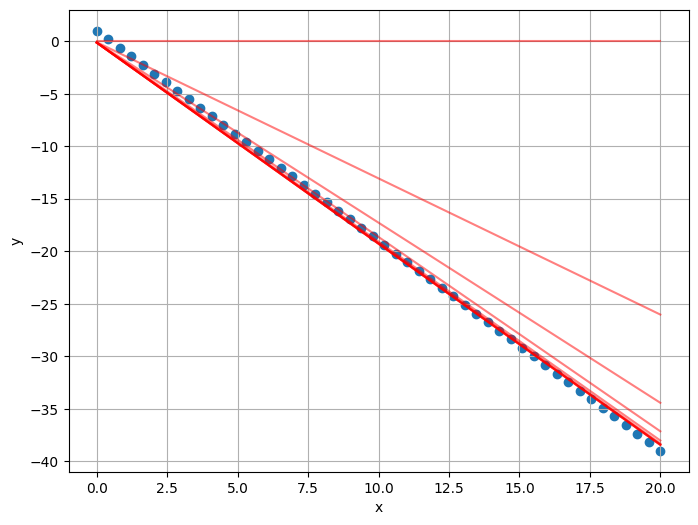

In [28]:
plot_all_regression(X, y, theta0h00, theta1h2)

## Stochastic GD

#### Update the implementation of the Batch GD to be Stochastic and rpeat the above plots and evaluations
#### You can try different learning rate and see its effect.
#### Compare to the Batch GD.
#### Do not forget to shuffle the data.

##### Very Important notes:
- <font color='red'>Save your losses and thetas for each iterations (not each epoch).</font>
- <font color='red'>Plot loss vs. iterations (not epochs). This will allow you to see the difference between SGD (stochastic GD) and batch GD.</font>
- <font color='red'>Convergence check should be performed each epoch not each iterations. This allows you to perform more accurate decision. This is because the noisy process could lead to a deciving decision.</font>
- <font color='red'>Your result may be different from the results shown below due to the randomness of the process. As well as, the random shuffle. The results will be different also for two different run of the algorithm.</font>
- <font color='red'><b>To obtain the same results use np.random.seed(101) before shuffle</b></font>

In [126]:
def SGD(x, y, alpha, iteration, tolerance=0.001):
    losses_SGD = []
    thetas_0SGD = []
    thetas_1SGD = []
    gradients_SGD = []

    m = len(x)
    theta_0 = 0
    theta_1 = 0

    epoch = 0

    while epoch < iteration:
        print(f"****************** Epoch {epoch} ********************\n")

        np.random.seed(101)
        indices = np.random.permutation(m)

        epoch_loss = 0

        for idx in indices:
            hx = theta_0 + theta_1 * x[idx]
            cost = 0.5 * (hx - y[idx])**2

            gradient_0 = (hx - y[idx])
            gradient_1 = (hx - y[idx]) * x[idx]

            theta_0 -= alpha * gradient_0
            theta_1 -= alpha * gradient_1

            losses_SGD.append(cost)
            gradients_SGD.append([gradient_0, gradient_1])
            thetas_0SGD.append(theta_0)
            thetas_1SGD.append(theta_1)

            epoch_loss += cost

        avg_loss = epoch_loss / m
        grad_norm = np.linalg.norm([gradient_0, gradient_1])

        print(f"Cost = {avg_loss}\n")
        print(f"Gradient Vector:")
        print(f"[[{gradient_0:>12.8f}]\n [{gradient_1:>12.8f}]]\n")
        print(f"Gradient Vector Norm:")
        print(f"{grad_norm}\n")
        print(f"theta_0_new : {theta_0}")
        print(f"theta_1_new : {theta_1}\n")

        if grad_norm < tolerance:
            print(f"****************** Training Report ********************\n")
            print(f"Gradient Descent converged after {epoch+1} epochs\n")
            print(f"theta_0_Opt : {theta_0}")
            print(f"theta_1_Opt : {theta_1}\n")
            print(f"Cost = {avg_loss}")
            break

        epoch += 1

    return losses_SGD, gradients_SGD, thetas_0SGD, thetas_1SGD

##### The following results uses alpha = 0.0005 and max. iterations = 300.

In [127]:
losses_SGD,gradients_SGD,thetas_0SGD,thetas_1SGD= SGD(X,y,0.0005,300)

****************** Epoch 0 ********************

Cost = 39.470422035279725

Gradient Vector:
[[  0.71006972]
 [  8.98455566]]

Gradient Vector Norm:
9.012571185993627

theta_0_new : -0.12761222125212127
theta_1_new : -1.8592841835063174

****************** Epoch 1 ********************

Cost = 0.20468403314238398

Gradient Vector:
[[  0.01883941]
 [  0.23837626]]

Gradient Vector Norm:
0.23911955711901475

theta_0_new : -0.12397684636948911
theta_1_new : -1.909800583000258

****************** Epoch 2 ********************

Cost = 0.16532306846563036

Gradient Vector:
[[  0.00026788]
 [  0.00338946]]

Gradient Vector Norm:
0.0034000305958517907

theta_0_new : -0.1168602386254817
theta_1_new : -1.9117125478064034

****************** Epoch 3 ********************

Cost = 0.1629475439361154

Gradient Vector:
[[ -0.00022960]
 [ -0.00290518]]

Gradient Vector Norm:
0.0029142431969663217

theta_0_new : -0.10969513711439667
theta_1_new : -1.9123149719506927

****************** Epoch 4 ***********

In [128]:
y_pred4=thetas_0SGD[-1]+thetas_1SGD[-1]*X
r2_score(y,y_pred4)

0.9997601748111716

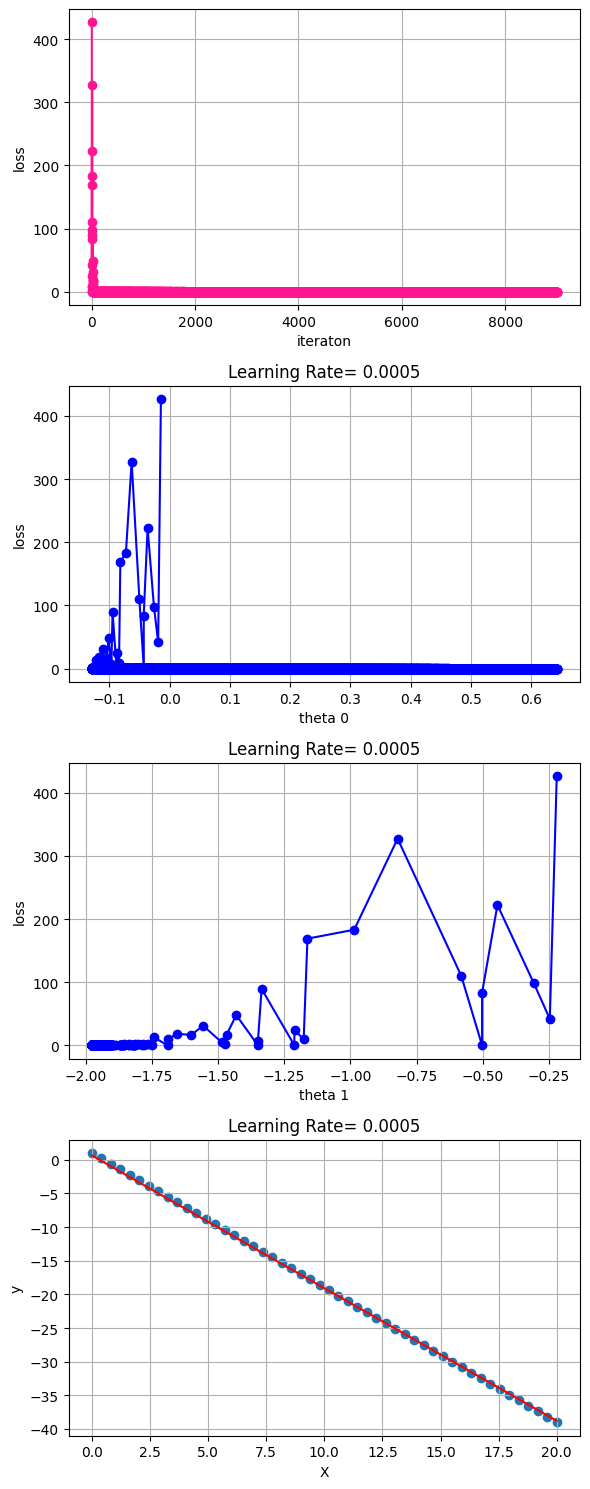

In [129]:
fig,plots=plt.subplots(4,1,figsize=(6,15))
plots[0].plot(losses_SGD,color="#FF1493",marker="o",linestyle="-")
plots[0].set_xlabel("iteraton")
plots[0].set_ylabel("loss")
plots[0].grid(True)

plots[1].plot(thetas_0SGD,losses_SGD,color="blue",marker="o",linestyle="-")
plots[1].set_xlabel("theta 0")
plots[1].set_ylabel("loss")
plots[1].set_title("Learning Rate= 0.0005")
plots[1].grid(True)


plots[2].plot(thetas_1SGD,losses_SGD,color="blue",marker="o",linestyle="-")
plots[2].set_xlabel("theta 1")
plots[2].set_ylabel("loss")
plots[2].set_title("Learning Rate= 0.0005")
plots[2].grid(True)

plots[3].scatter(X,y)
plots[3].plot(X,y_pred4,color="red")
plots[3].set_xlabel("X")
plots[3].set_ylabel("y")
plots[3].set_title("Learning Rate= 0.0005")
plots[3].grid(True)


plt.tight_layout()
plt.show()


##### The following results uses alpha = 0.0001 and max. iterations = 300.

In [133]:
losses_SGD,gradients_SGD,thetas_0SGD,thetas_1SGD= SGD(X,y,0.00001,300)

****************** Epoch 0 ********************

Cost = 234.28046496482196

Gradient Vector:
[[ 22.74505093]
 [287.79452199]]

Gradient Vector Norm:
288.69191923132394

theta_0_new : -0.009179767057806557
theta_1_new : -0.12554543045584546

****************** Epoch 1 ********************

Cost = 204.59384752172042

Gradient Vector:
[[ 21.24966618]
 [268.87332717]]

Gradient Vector Norm:
269.7117245812656

theta_0_new : -0.017748183901183268
theta_1_new : -0.24286148895526452

****************** Epoch 2 ********************

Cost = 178.67173148316203

Gradient Vector:
[[ 19.85231138]
 [251.19251139]]

Gradient Vector Norm:
251.97577669982857

theta_0_new : -0.025745328596044087
theta_1_new : -0.35248764887196493

****************** Epoch 3 ********************

Cost = 156.0367405436724

Gradient Vector:
[[ 18.54656023]
 [234.67076204]]

Gradient Vector Norm:
235.40250944483319

theta_0_new : -0.033208651905211405
theta_1_new : -0.4549280186002072

****************** Epoch 4 ************

In [134]:
y_pred4=thetas_0SGD[-1]+thetas_1SGD[-1]*X
r2_score(y,y_pred4)

0.9977574017129232

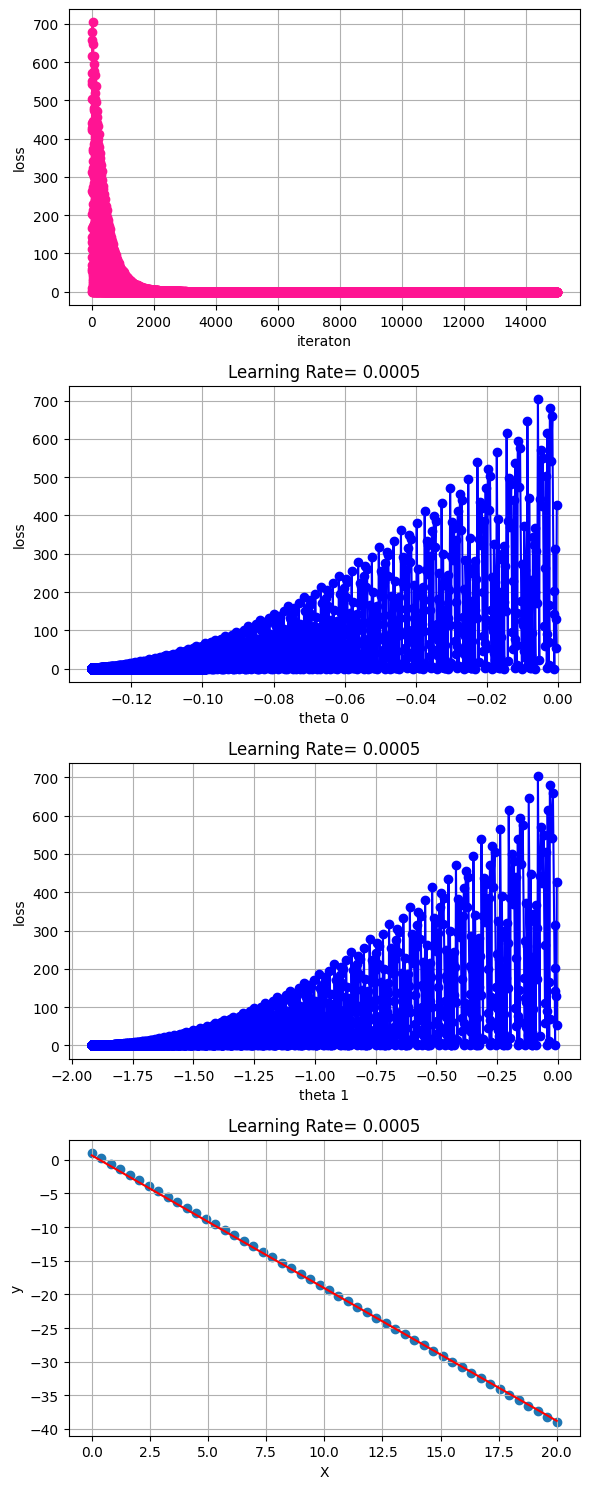

In [131]:
fig,plots=plt.subplots(4,1,figsize=(6,15))
plots[0].plot(losses_SGD,color="#FF1493",marker="o",linestyle="-")
plots[0].set_xlabel("iteraton")
plots[0].set_ylabel("loss")
plots[0].grid(True)

plots[1].plot(thetas_0SGD,losses_SGD,color="blue",marker="o",linestyle="-")
plots[1].set_xlabel("theta 0")
plots[1].set_ylabel("loss")
plots[1].set_title("Learning Rate= 0.0005")
plots[1].grid(True)


plots[2].plot(thetas_1SGD,losses_SGD,color="blue",marker="o",linestyle="-")
plots[2].set_xlabel("theta 1")
plots[2].set_ylabel("loss")
plots[2].set_title("Learning Rate= 0.0005")
plots[2].grid(True)

plots[3].scatter(X,y)
plots[3].plot(X,y_pred4,color="red")
plots[3].set_xlabel("X")
plots[3].set_ylabel("y")
plots[3].set_title("Learning Rate= 0.0005")
plots[3].grid(True)


plt.tight_layout()
plt.show()


##### The following results uses alpha = 0.00007 and max. iterations = 300.

In [135]:
losses_SGD,gradients_SGD,thetas_0SGD,thetas_1SGD= SGD(X,y,0.00007,300)

****************** Epoch 0 ********************

Cost = 163.82680552285262

Gradient Vector:
[[ 15.21676482]
 [192.53865685]]

Gradient Vector Norm:
193.13902845642275

theta_0_new : -0.0526625963181957
theta_1_new : -0.7277523032709559

****************** Epoch 1 ********************

Cost = 63.09941487240788

Gradient Vector:
[[  9.41022657]
 [119.06817298]]

Gradient Vector Norm:
119.43944985086782

theta_0_new : -0.08492087485410607
theta_1_new : -1.1789316302972381

****************** Epoch 2 ********************

Cost = 24.375252157053815

Gradient Vector:
[[  5.81064181]
 [ 73.52240662]]

Gradient Vector Norm:
73.75166325784151

theta_0_new : -0.10453040045312463
theta_1_new : -1.4586570394661047

****************** Epoch 3 ********************

Cost = 9.484528074710374

Gradient Vector:
[[  3.57919780]
 [ 45.28780888]]

Gradient Vector Norm:
45.42902475523053

theta_0_new : -0.11629902421809676
theta_1_new : -1.6320942310148396

****************** Epoch 4 ********************



In [136]:
y_pred4=thetas_0SGD[-1]+thetas_1SGD[-1]*X
r2_score(y,y_pred4)

0.9985893285430332

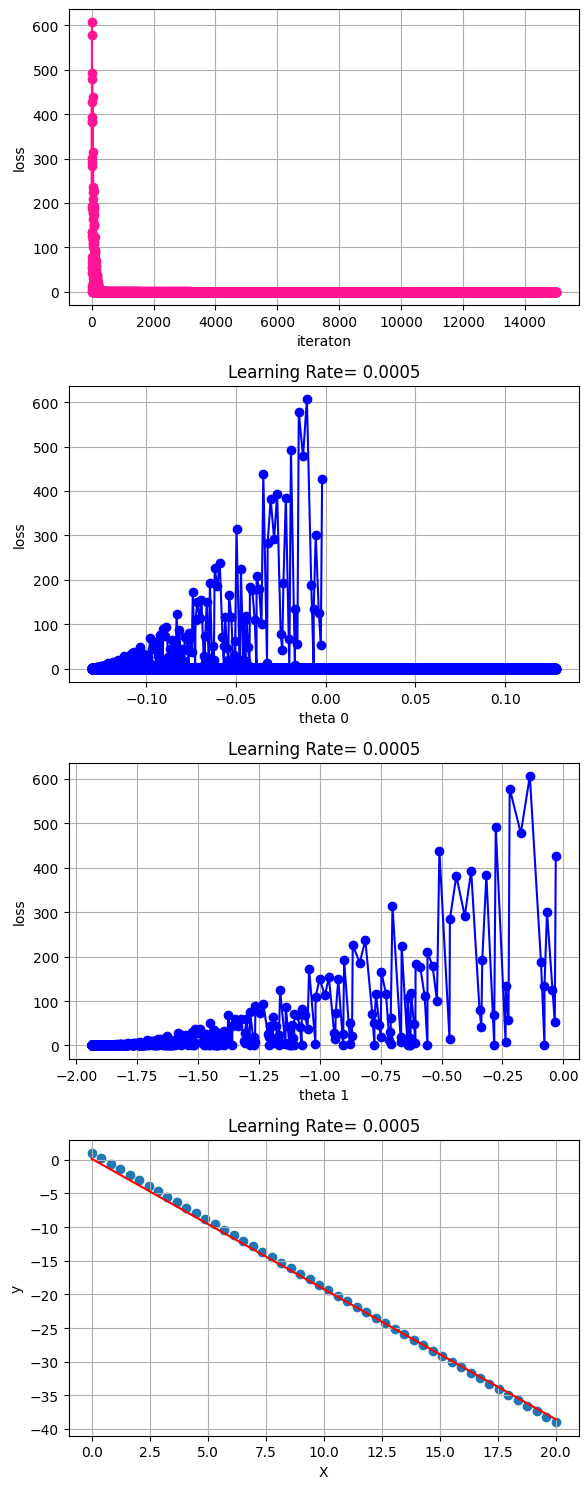

In [137]:
fig,plots=plt.subplots(4,1,figsize=(6,15))
plots[0].plot(losses_SGD,color="#FF1493",marker="o",linestyle="-")
plots[0].set_xlabel("iteraton")
plots[0].set_ylabel("loss")
plots[0].grid(True)

plots[1].plot(thetas_0SGD,losses_SGD,color="blue",marker="o",linestyle="-")
plots[1].set_xlabel("theta 0")
plots[1].set_ylabel("loss")
plots[1].set_title("Learning Rate= 0.0005")
plots[1].grid(True)


plots[2].plot(thetas_1SGD,losses_SGD,color="blue",marker="o",linestyle="-")
plots[2].set_xlabel("theta 1")
plots[2].set_ylabel("loss")
plots[2].set_title("Learning Rate= 0.0005")
plots[2].grid(True)

plots[3].scatter(X,y)
plots[3].plot(X,y_pred4,color="red")
plots[3].set_xlabel("X")
plots[3].set_ylabel("y")
plots[3].set_title("Learning Rate= 0.0005")
plots[3].grid(True)


plt.tight_layout()
plt.show()


## Mini-Batch GD

#### Update the implementation of the Batch GD to be Mini-Batch and repeat the above plots and evaluations
#### Change batch size and see the effect
#### Do not forget to shuffle the data

##### Very Important notes:
- <font color='red'>Save your losses and thetas for each iterations (not each epoch).</font>
- <font color='red'>Plot loss vs. iterations (not epochs). This will allow you to see the difference between SGD (stochastic GD) and batch GD.</font>
- <font color='red'>Convergence check should be performed each epoch not each iterations. This allows you to perform more accurate decision. This is because the noisy process could lead to a deciving decision.</font>
-<font color='red'>Your result may be different from the results shown below due to the randomness of the process. As well as, the random shuffle. The results will be different also for two different run of the algorithm.</font>
- <font color='red'><b>To obtain the same results use np.random.seed(101) before shuffle</b></font>

In [138]:
def mini_batch_GD(x, y, alpha, batch_size, iteration, tolerance=0.001):
    losses_mini = []
    thetas_0_mini = []
    thetas_1_mini = []
    gradients_mini = []

    m = len(x)
    theta_0 = 0
    theta_1 = 0

    epoch = 0

    while epoch < iteration:
        print(f"****************** Epoch {epoch} ********************\n")

        np.random.seed(101)
        indices = np.random.permutation(m)

        epoch_loss = 0
        num_batches = 0

        for i in range(0, m, batch_size):
            batch_indices = indices[i:i+batch_size]

            gradient_0_sum = 0
            gradient_1_sum = 0
            batch_loss = 0

            for idx in batch_indices:
                hx = theta_0 + theta_1 * x[idx]
                cost = 0.5 * (hx - y[idx])**2

                gradient_0_sum += (hx - y[idx])
                gradient_1_sum += (hx - y[idx]) * x[idx]

                batch_loss += cost

            batch_len = len(batch_indices)
            gradient_0 = gradient_0_sum / batch_len
            gradient_1 = gradient_1_sum / batch_len

            theta_0 -= alpha * gradient_0
            theta_1 -= alpha * gradient_1

            losses_mini.append(batch_loss / batch_len)
            gradients_mini.append([gradient_0, gradient_1])
            thetas_0_mini.append(theta_0)
            thetas_1_mini.append(theta_1)

            epoch_loss += batch_loss
            num_batches += 1

        avg_loss = epoch_loss / m
        grad_norm = np.linalg.norm([gradient_0, gradient_1])

        print(f"Cost = {avg_loss}\n")
        print(f"Gradient Vector:")
        print(f"[[{gradient_0:>12.8f}]\n [{gradient_1:>12.8f}]]\n")
        print(f"Gradient Vector Norm:")
        print(f"{grad_norm}\n")
        print(f"theta_0_new : {theta_0}")
        print(f"theta_1_new : {theta_1}\n")

        if grad_norm < tolerance:
            print(f"****************** Training Report ********************\n")
            print(f"Gradient Descent converged after {epoch+1} epochs\n")
            print(f"theta_0_Opt : {theta_0}")
            print(f"theta_1_Opt : {theta_1}\n")
            print(f"Cost = {avg_loss}")
            break

        epoch += 1

    return losses_mini, gradients_mini, thetas_0_mini, thetas_1_mini

##### The following results uses batch size=5, alpha = 0.0005 and max. iterations = 300.

In [148]:
losses_mini, gradients_mini, thetas_0_mini, thetas_1_mini= mini_batch_GD(X,y,0.0005,5,20)

****************** Epoch 0 ********************

Cost = 145.77747144624746

Gradient Vector:
[[  6.55556162]
 [ 60.78163510]]

Gradient Vector Norm:
61.13413574891091

theta_0_new : -0.06978924724113063
theta_1_new : -0.9693635987180408

****************** Epoch 1 ********************

Cost = 35.714317832049026

Gradient Vector:
[[  2.96619847]
 [ 28.61439115]]

Gradient Vector Norm:
28.767719999075442

theta_0_new : -0.103504017832776
theta_1_new : -1.44799256525687

****************** Epoch 2 ********************

Cost = 8.859188609237764

Gradient Vector:
[[  1.19448224]
 [ 12.73525899]]

Gradient Vector Norm:
12.791153559071402

theta_0_new : -0.11940982177970424
theta_1_new : -1.6843464761632723

****************** Epoch 3 ********************

Cost = 2.299335899730069

Gradient Vector:
[[  0.32013523]
 [  4.89754198]]

Gradient Vector Norm:
4.9079938882509655

theta_0_new : -0.12652431396007574
theta_1_new : -1.8010894682190426

****************** Epoch 4 ********************

Co

In [149]:
y_pred5=thetas_0_mini[-1]+thetas_1_mini[-1]*X
r2_score(y,y_pred5)

0.9977050042274415

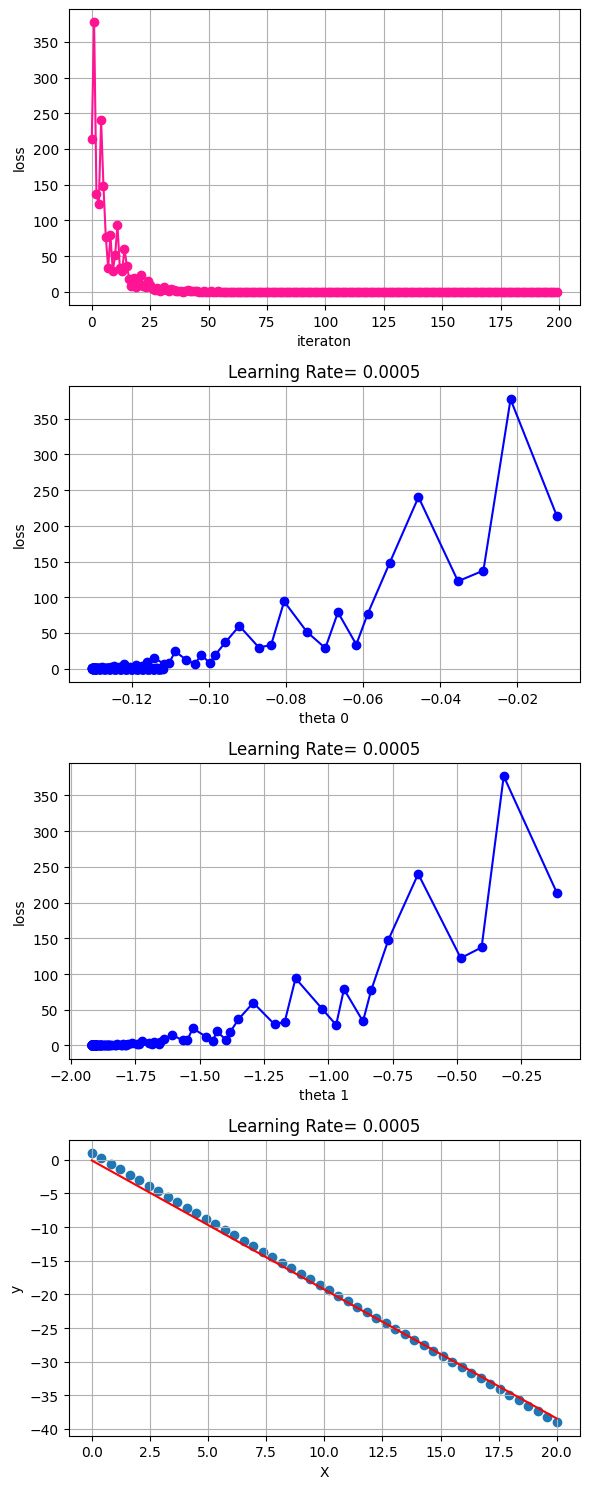

In [151]:
fig,plots=plt.subplots(4,1,figsize=(6,15))
plots[0].plot(losses_mini,color="#FF1493",marker="o",linestyle="-")
plots[0].set_xlabel("iteraton")
plots[0].set_ylabel("loss")
plots[0].grid(True)

plots[1].plot(thetas_0_mini,losses_mini,color="blue",marker="o",linestyle="-")
plots[1].set_xlabel("theta 0")
plots[1].set_ylabel("loss")
plots[1].set_title("Learning Rate= 0.0005")
plots[1].grid(True)


plots[2].plot(thetas_1_mini,losses_mini,color="blue",marker="o",linestyle="-")
plots[2].set_xlabel("theta 1")
plots[2].set_ylabel("loss")
plots[2].set_title("Learning Rate= 0.0005")
plots[2].grid(True)

plots[3].scatter(X,y)
plots[3].plot(X,y_pred5,color="red")
plots[3].set_xlabel("X")
plots[3].set_ylabel("y")
plots[3].set_title("Learning Rate= 0.0005")
plots[3].grid(True)


plt.tight_layout()
plt.show()


##### The following results uses batch size=10, alpha = 0.0005 and max. iterations = 300.

In [152]:
losses_mini, gradients_mini, thetas_0_mini, thetas_1_mini= mini_batch_GD(X,y,0.0005,10,20)

****************** Epoch 0 ********************

Cost = 194.14331348574814

Gradient Vector:
[[ 11.36405540]
 [144.44648550]]

Gradient Vector Norm:
144.89281876537092

theta_0_new : -0.04124848216567694
theta_1_new : -0.5683087110235961

****************** Epoch 1 ********************

Cost = 96.12235720338664

Gradient Vector:
[[  7.86063891]
 [101.34687856]]

Gradient Vector Norm:
101.65126382467814

theta_0_new : -0.07003863931709524
theta_1_new : -0.9679738990170041

****************** Epoch 2 ********************

Cost = 47.63986244890192

Gradient Vector:
[[  5.39703213]
 [ 71.03829803]]

Gradient Vector Norm:
71.24301890211146

theta_0_new : -0.0900679276338996
theta_1_new : -1.2490447040747128

****************** Epoch 3 ********************

Cost = 23.657936948974847

Gradient Vector:
[[  3.66464568]
 [ 49.72468931]]

Gradient Vector Norm:
49.85954627699759

theta_0_new : -0.10393649132998092
theta_1_new : -1.4467169419665995

****************** Epoch 4 ********************



In [153]:
y_pred5=thetas_0_mini[-1]+thetas_1_mini[-1]*X
r2_score(y,y_pred5)

0.9976389273579023

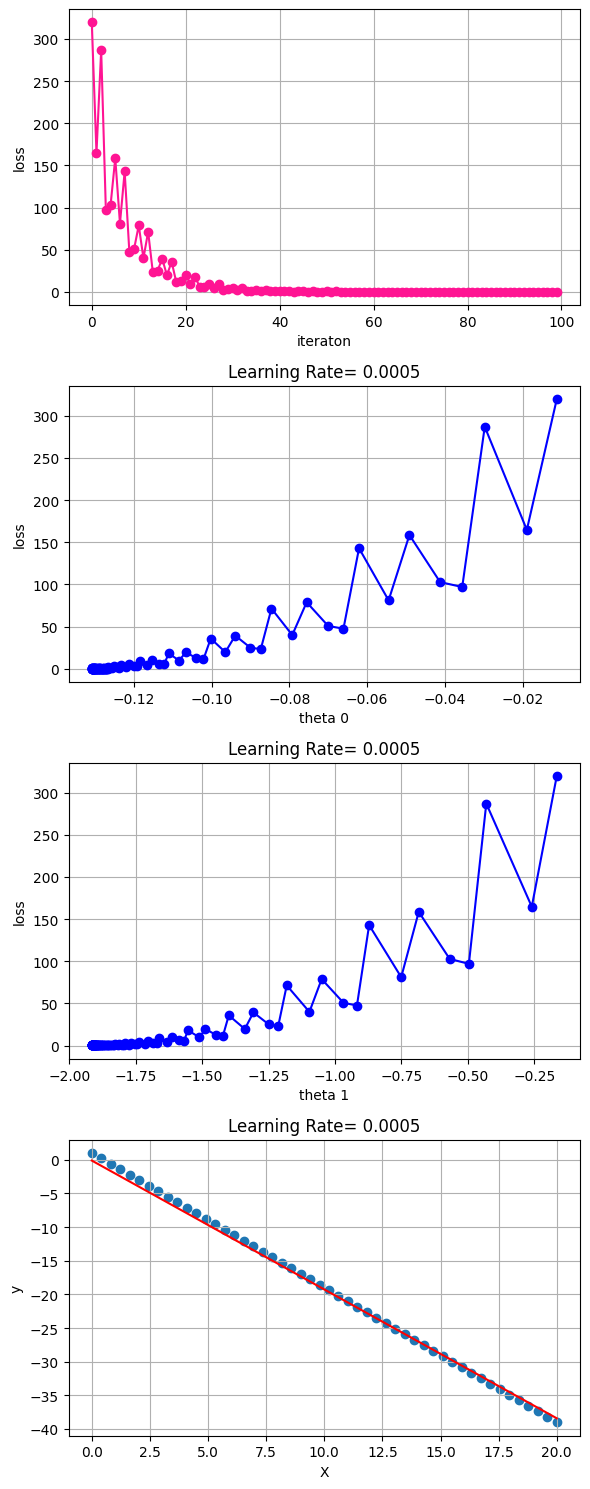

In [154]:
fig,plots=plt.subplots(4,1,figsize=(6,15))
plots[0].plot(losses_mini,color="#FF1493",marker="o",linestyle="-")
plots[0].set_xlabel("iteraton")
plots[0].set_ylabel("loss")
plots[0].grid(True)

plots[1].plot(thetas_0_mini,losses_mini,color="blue",marker="o",linestyle="-")
plots[1].set_xlabel("theta 0")
plots[1].set_ylabel("loss")
plots[1].set_title("Learning Rate= 0.0005")
plots[1].grid(True)


plots[2].plot(thetas_1_mini,losses_mini,color="blue",marker="o",linestyle="-")
plots[2].set_xlabel("theta 1")
plots[2].set_ylabel("loss")
plots[2].set_title("Learning Rate= 0.0005")
plots[2].grid(True)

plots[3].scatter(X,y)
plots[3].plot(X,y_pred5,color="red")
plots[3].set_xlabel("X")
plots[3].set_ylabel("y")
plots[3].set_title("Learning Rate= 0.0005")
plots[3].grid(True)


plt.tight_layout()
plt.show()


##### The following results uses batch size=20, alpha = 0.0005 and max. iterations = 300.

In [155]:
losses_mini, gradients_mini, thetas_0_mini, thetas_1_mini= mini_batch_GD(X,y,0.0005,20,20)

****************** Epoch 0 ********************

Cost = 225.47826195255874

Gradient Vector:
[[ 13.28117888]
 [168.03253493]]

Gradient Vector Norm:
168.5565854723684

theta_0_new : -0.025806910494062956
theta_1_new : -0.34956845854908747

****************** Epoch 1 ********************

Cost = 150.73429374844324

Gradient Vector:
[[ 10.77607508]
 [137.21606657]]

Gradient Vector Norm:
137.6385582583373

theta_0_new : -0.04681622152392541
theta_1_new : -0.6352969942726102

****************** Epoch 2 ********************

Cost = 100.79206446150798

Gradient Vector:
[[  8.72854325]
 [112.02806465]]

Gradient Vector Norm:
112.36758756895237

theta_0_new : -0.06390421550487006
theta_1_new : -0.8688455261450846

****************** Epoch 3 ********************

Cost = 67.42061888195545

Gradient Vector:
[[  7.05501102]
 [ 91.44052857]]

Gradient Vector Norm:
91.71228622737434

theta_0_new : -0.07778712789992066
theta_1_new : -1.0597443693715909

****************** Epoch 4 *******************

In [156]:
y_pred5=thetas_0_mini[-1]+thetas_1_mini[-1]*X
r2_score(y,y_pred5)

0.9964049892302772

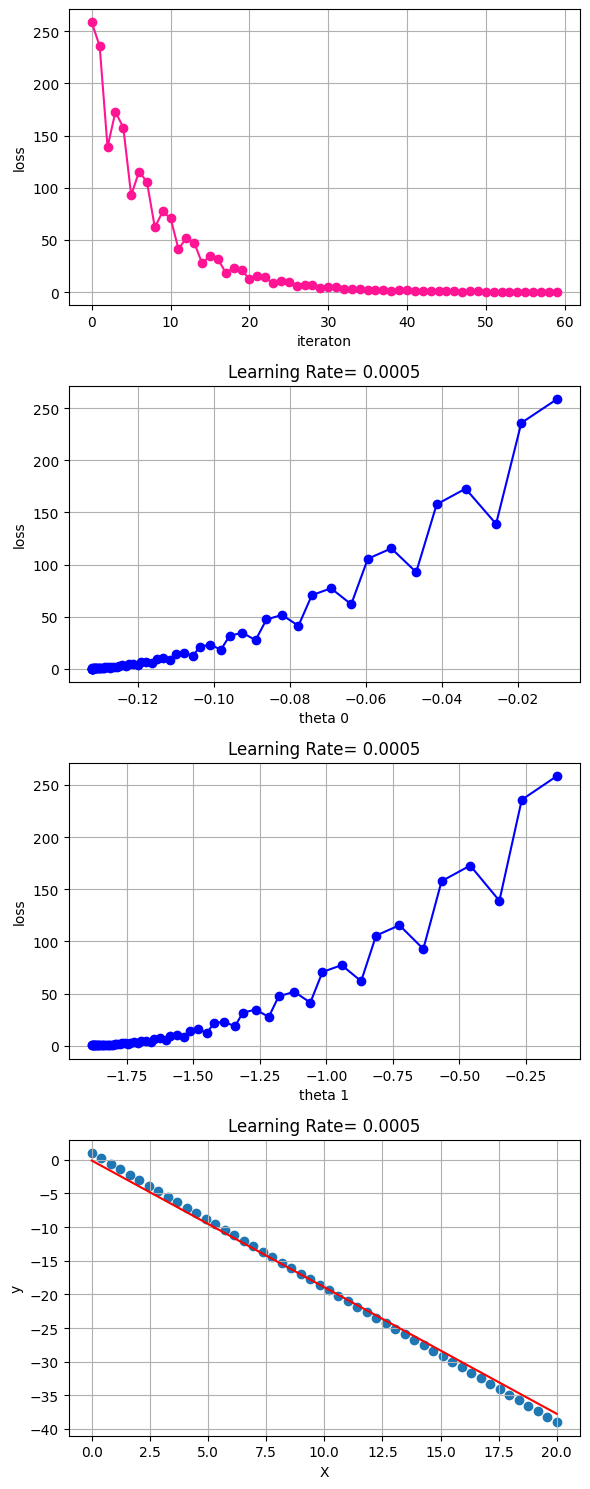

In [157]:
fig,plots=plt.subplots(4,1,figsize=(6,15))
plots[0].plot(losses_mini,color="#FF1493",marker="o",linestyle="-")
plots[0].set_xlabel("iteraton")
plots[0].set_ylabel("loss")
plots[0].grid(True)

plots[1].plot(thetas_0_mini,losses_mini,color="blue",marker="o",linestyle="-")
plots[1].set_xlabel("theta 0")
plots[1].set_ylabel("loss")
plots[1].set_title("Learning Rate= 0.0005")
plots[1].grid(True)


plots[2].plot(thetas_1_mini,losses_mini,color="blue",marker="o",linestyle="-")
plots[2].set_xlabel("theta 1")
plots[2].set_ylabel("loss")
plots[2].set_title("Learning Rate= 0.0005")
plots[2].grid(True)

plots[3].scatter(X,y)
plots[3].plot(X,y_pred5,color="red")
plots[3].set_xlabel("X")
plots[3].set_ylabel("y")
plots[3].set_title("Learning Rate= 0.0005")
plots[3].grid(True)


plt.tight_layout()
plt.show()


In [168]:
from IPython.display import HTML, display, Markdown

display(Markdown("### When you finally understand the difference between SGD and Mini-Batch GD 😂"))
display(HTML('<img src="https://i.imgflip.com/4/1bij.jpg" width="500">'))

### When you finally understand the difference between SGD and Mini-Batch GD 😂